In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [2]:
img = cv2.imread("image_01.png")[:, :, ::-1]
exmask = cv2.imread("exudates_mask.png", cv2.IMREAD_GRAYSCALE)
vesmask = cv2.imread("vessels_mask.png", cv2.IMREAD_GRAYSCALE)


def get_mask_bounding_box(mask):
    mask = mask > 0
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, rmax, cmin, cmax

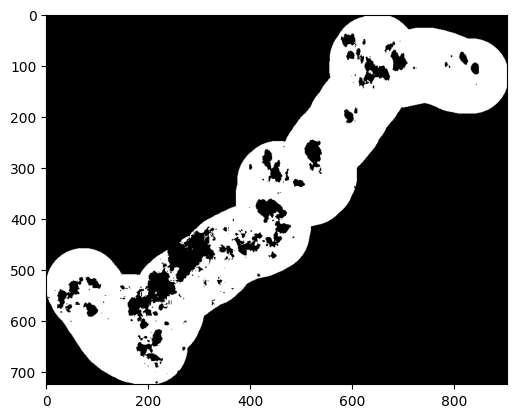

In [3]:
from skimage.feature import canny

from skimage.filters import (
    try_all_threshold,
    threshold_multiotsu,
    threshold_isodata,
    threshold_mean,
    threshold_otsu,
    threshold_yen,
    threshold_sauvola,
    threshold_niblack,
)


test_mask = exmask

bb_ex = get_mask_bounding_box(test_mask)
roi_img = img[bb_ex[0] : bb_ex[1], bb_ex[2] : bb_ex[3]]
roi_mask = test_mask[bb_ex[0] : bb_ex[1], bb_ex[2] : bb_ex[3]].astype(bool)

roi_img = cv2.cvtColor(roi_img, cv2.COLOR_RGB2GRAY) / 255.0


t = threshold_otsu(roi_img[roi_mask])
# t = threshold_yen(roi_img[roi_mask])
# t = threshold_mean(roi_img[roi_mask])
# t = threshold_isodata(roi_img[roi_mask])
# t = threshold_sauvola(roi_img[roi_mask])
# t = threshold_niblack(1-roi_img[roi_mask])
v = roi_img[roi_mask] < t
refined_mask = np.zeros_like(roi_mask)
refined_mask[roi_mask] = v
plt.imshow(refined_mask, cmap="gray")

plt.show()

(534, 804) (534, 804)


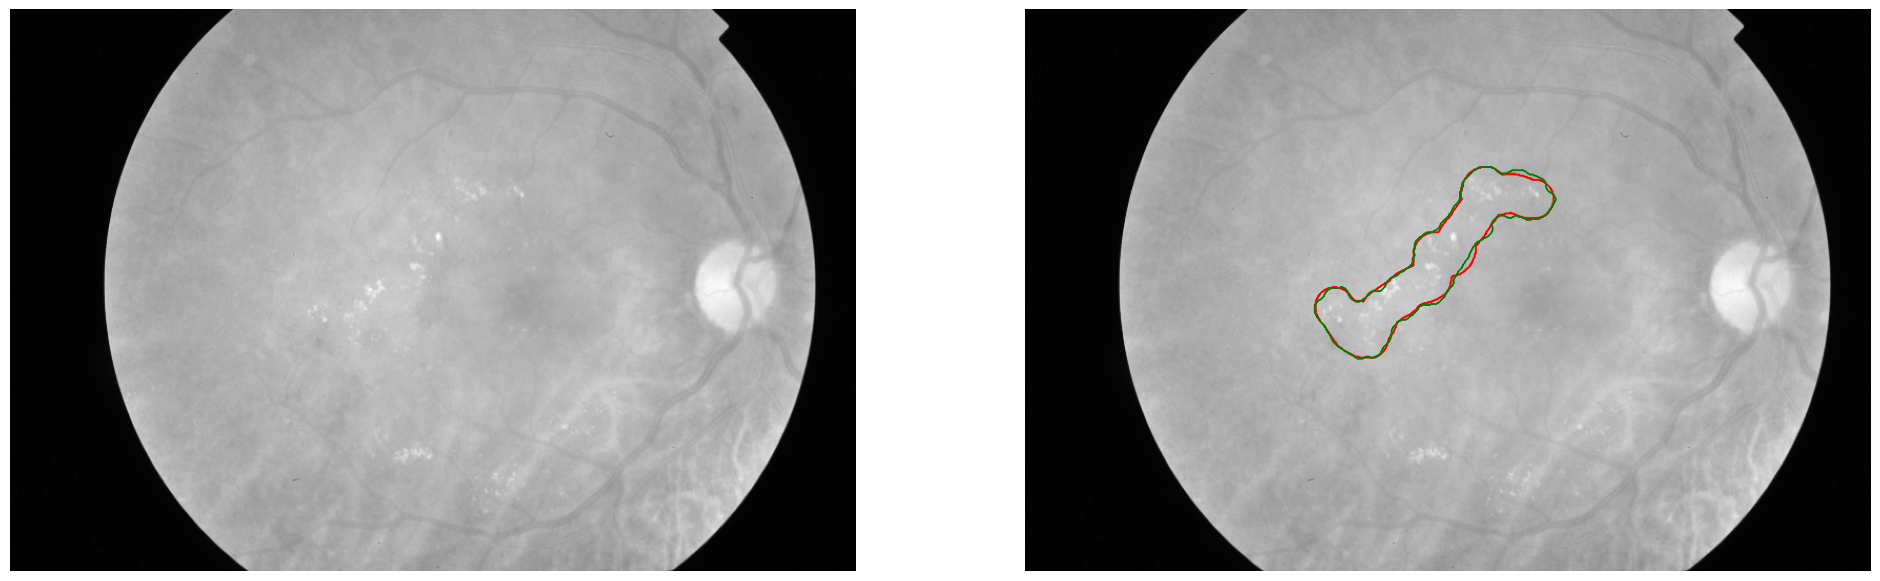

In [40]:
from skimage.segmentation import (
    morphological_geodesic_active_contour,
    morphological_chan_vese,
)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
mask = exmask > 0
test_img = cv2.resize(img, fx=0.25, fy=0.25, dsize=None).max(2).astype(np.float32)
test_mask = cv2.resize(exmask, fx=0.25, fy=0.25, dsize=None).astype(np.float32)

print(test_mask.shape, test_img.shape)

refined_mask = morphological_geodesic_active_contour(
    test_img, num_iter=25, init_level_set=test_mask, smoothing=5, balloon=-0.75
)
axes[0].imshow(test_img, cmap="gray")
axes[0].axis("off")

axes[1].imshow(test_img, cmap="gray")
axes[1].contour(test_mask, colors="r", linewidths=0.5)
axes[1].contour(refined_mask, colors="g", linewidths=0.5)
axes[1].axis("off")

plt.show()